## Isolation Forest for detecting Anomalis/Outliers


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [11]:
df = pd.read_csv("thyroid_dataset.csv")

In [12]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [13]:
X = df.drop("Outlier_label", axis=1)
y = df["Outlier_label"]

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [21]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(
    n_estimators=200, 
    contamination=0.0361, #thyroid dataset contains 3.61% outliers
    random_state=42)
labels = clf.fit_predict(X_scaled)
labels

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

In [22]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

Text(0.5, 1.0, 'Anomalies in Thyroid datasets')

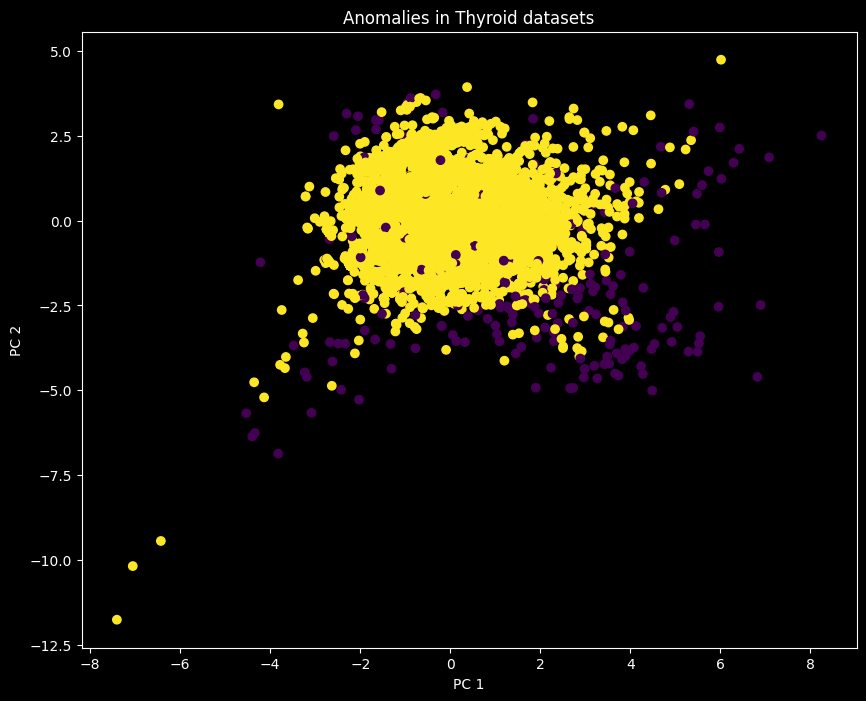

In [23]:
plt.figure(figsize=(10,8))
plt.scatter(x=X_pca[:,0], y=X_pca[:, 1], c= labels)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Anomalies in Thyroid datasets")

In [24]:
import numpy as np

outliers = np.sum(labels==-1)
normal = np.sum(labels==1)
print(outliers, normal)

250 6666
